In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.special import expit
from tqdm import tqdm

from lrpa import calculate_mu, tensor, BernalBilayer, RhombohedralMultilayer

## basic tools

In [2]:
def gen_kpath(points, n=151):
    points = np.asarray(points, dtype=float)
    lengths = np.linalg.norm(np.diff(points, axis=0), axis=1)
    total = np.sum(lengths)

    if total == 0:
        raise ValueError("The k-path has zero length.")

    nseg = np.maximum(2, np.round((n - 1) * lengths / total).astype(int))
    nseg[-1] += (n - 1) - np.sum(nseg)

    path = []
    ticks = [0]

    for i, ni in enumerate(nseg):
        endpoint = (i == len(nseg) - 1)
        seg = np.linspace(points[i], points[i + 1], ni + int(endpoint), endpoint=endpoint)
        if i > 0:
            seg = seg[1:]
        path.append(seg)
        ticks.append(ticks[-1] + len(seg) - 1)

    km = np.vstack(path)
    return km.T, ticks


def full_kpath(n=151):
    kpt = np.array([
        [2/3, 1/3],   # K-
        [0.0, 0.0],   # Gamma
        [1/3, 2/3],   # K+
        [0.0, 1/2],   # M
    ])
    labels = [r"$\rm K_-$", r"$\rm \Gamma$", r"$\rm K_+$", r"$\rm M$"]
    km, ticks = gen_kpath(kpt, n=n)
    return km, ticks, labels


def mini_kpath(k0=0.04, n=151, kind="corner"):
    if kind == "corner":
        kpt = np.array([
            [k0, 0.0],
            [0.0, 0.0],
            [0.0, k0],
        ])
        labels = [r"$\rm K+k_x$", r"$\rm K$", r"$\rm K+k_y$"]
    elif kind == "line":
        kpt = np.array([
            [-k0, 0.0],
            [0.0, 0.0],
            [ k0, 0.0],
        ])
        labels = [r"$\rm K-k_x$", r"$\rm K$", r"$\rm K+k_x$"]
    else:
        raise ValueError("kind must be 'corner' or 'line'.")

    km, ticks = gen_kpath(kpt, n=n)
    return km, ticks, labels


def plot_band(e, EF=None, Erange=None, ax=None, 
              color="k", mode="line", lw=0.8, s=2, title=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6.0, 4.0))

    e = np.asarray(e)
    nk, nb = e.shape

    if EF is None:
        vals = np.sort(e.ravel())
        mid = len(vals) // 2
        EF = 0.5 * (vals[mid - 1] + vals[mid])

    x = np.arange(nk)

    for ib in range(nb):
        if mode == "dot":
            ax.scatter(x, e[:, ib] - EF, s=s, c=color)
        else:
            ax.plot(x, e[:, ib] - EF, c=color, lw=lw)

    ax.axhline(0.0, color="black", ls="--", lw=0.6)
    ax.set_xlim(0, nk - 1)
    if Erange is not None:
        ax.set_ylim(-Erange, Erange)

    ax.set_ylabel("Energy (eV)")
    if title is not None:
        ax.set_title(title)

    return ax

## band examples

196


Text(0.5, 1.0, 'twisted model')

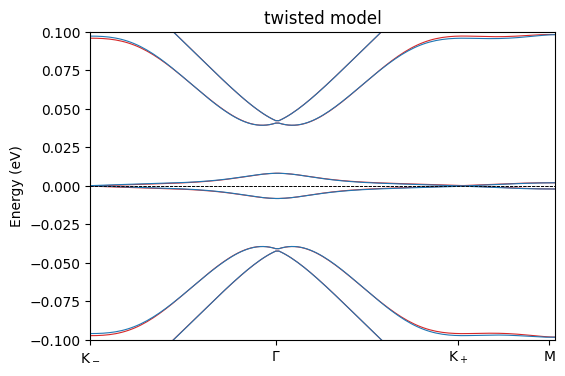

In [3]:
# Twisted continuum example
model = RhombohedralMultilayer(V=5, nlayer=2, theta=1.08, gamma3=0, gamma4=0)
km, xtp, xtk = full_kpath(n=151)

model.k = km
model.nk = model.k.shape[1]
model.calculate_bandstructure()
print(model.Ndim)

fig, ax = plt.subplots(figsize=(6.0, 4.0))
plot_band(model.e[0], EF=0, Erange=0.1, ax=ax, color="tab:red")
plot_band(model.e[1], EF=0, Erange=0.1, ax=ax, color="tab:blue")
plt.xticks(xtp,xtk)
ax.set_title("twisted model")

## vertex tensor

In [4]:
def tensor(V0, V1=None, J=0.0):
    if V1 is None:
        V1 = V0

    U4 = np.zeros((4, 4, 4, 4), dtype=float)

    def add_density_pair(p, q, x):
        U4[p, q, q, p] += x
        U4[q, p, p, q] += x
        U4[p, p, q, q] -= x
        U4[q, q, p, p] -= x

    # V0: same valley, opposite spin
    add_density_pair(0, 2, V0)   # up0, dn0
    add_density_pair(1, 3, V0)   # up1, dn1

    # V1: different valley, all spin combinations
    add_density_pair(0, 1, V1)   # up0, up1
    add_density_pair(0, 3, V1)   # up0, dn1
    add_density_pair(2, 1, V1)   # dn0, up1
    add_density_pair(2, 3, V1)   # dn0, dn1

    if J != 0.0:
        # Hund coupling / exchange

        a = np.array([0, 0, 1, 1, 2, 2, 3, 3])
        b = np.array([0, 2, 1, 3, 0, 2, 1, 3])
        c = np.array([3, 3, 2, 2, 1, 1, 0, 0])
        d = np.array([3, 1, 2, 0, 3, 1, 2, 0])
        U4[a, b, c, d] += J

        a = np.array([0, 0, 1, 1, 2, 2, 3, 3])
        b = np.array([1, 3, 0, 2, 1, 3, 0, 2])
        c = np.array([3, 3, 2, 2, 1, 1, 0, 0])
        d = np.array([2, 0, 3, 1, 2, 0, 3, 1])
        U4[a, b, c, d] -= J

        a = np.array([0, 1, 2, 3])
        b = np.array([0, 1, 2, 3])
        c = np.array([1, 0, 3, 2])
        d = np.array([1, 0, 3, 2])
        U4[a, b, c, d] += 2 * J

        a = np.array([0, 1, 2, 3])
        b = np.array([1, 0, 3, 2])
        c = np.array([1, 0, 3, 2])
        d = np.array([0, 1, 2, 3])
        U4[a, b, c, d] -= 2 * J

    return U4

In [5]:
perm = lambda T, p: T.transpose(
    *range(T.ndim - len(p)),
    *(T.ndim - len(p) + i for i in p)
)

ph_t2m = lambda T: perm(T, (0,1,3,2)).reshape(*T.shape[:-4], 16, 16)
ph_m2t = lambda M: perm(M.reshape(*M.shape[:-2], 4,4,4,4), (0,1,3,2))

pp_t2m = lambda T: perm(T, (2,0,1,3)).reshape(*T.shape[:-4], 16, 16)
pp_m2t = lambda M: perm(M.reshape(*M.shape[:-2], 4,4,4,4), (1,2,0,3))

ph4_t2m = lambda T: perm(T, (0,1,3,2)).reshape(*T.shape[:-4], 4, 4)
pp4_t2m = lambda T: perm(T, (2,0,1,3)).reshape(*T.shape[:-4], 4, 4)

def split_vertex(U_4, chi_ph=None, chi_pp=None):
    U_4 = U_4

    U4_to_8 = lambda T: perm(
        T.reshape(*T.shape[:-4], 2,2,2,2,2,2,2,2),
        (0,2,4,6,1,3,5,7)
    )

    def embed_chi(chi):
        chi = np.asarray(chi)
        chi8 = np.zeros((*chi.shape[:-4], 2,2,2,2,2,2,2,2), dtype=chi.dtype)

        for s in range(2):
            chi8[..., s, s, s, s, :, :, :, :] = chi
            chi8[..., s, 1-s, 1-s, s, :, :, :, :] = chi

        return perm(chi8, (0,4,1,5,2,6,3,7)).reshape(*chi.shape[:-4], 4,4,4,4)

    U_8 = U4_to_8(U_4)

    U_d = U_8[0,0,1,1] + U_8[0,0,0,0]
    U_m = U_8[0,0,1,1] - U_8[0,0,0,0]
    
    U_s = U_8[0,0,1,1] - U_8[0,1,1,0]
    U_t = U_8[0,0,1,1] + U_8[0,1,1,0]

    out = {
        "Vd": ph4_t2m(U_d),
        "Vm": ph4_t2m(U_m),
        "Vs": pp4_t2m(U_s),
        "Vt": pp4_t2m(U_t),
    }

    if chi_ph is None and chi_pp is None:
        return out

    U_ph = ph_t2m(U_4)
    U_pp = pp_t2m(U_4)
    I = np.eye(16)

    chi_ph_mat = ph_t2m(embed_chi(chi_ph))
    Phi_ph = ph_m2t(np.linalg.solve(I - U_ph @ chi_ph_mat, U_ph) - U_ph)
    # l_rpa = np.linalg.eigvals(U_ph @ chi_ph_mat)
    # assert (l_rpa<1).all()

    vPhi_ph = -perm(Phi_ph, (2,1,0,3))

    chi_pp_mat = pp_t2m(embed_chi(chi_pp))
    Phi_pp = pp_m2t(np.linalg.solve(I - 0.5 * U_pp @ chi_pp_mat, U_pp) - U_pp)

    V8_pair = U4_to_8(U_4 + Phi_ph + vPhi_ph)

    Vs4 = V8_pair[...,0,0,1,1,:,:,:,:] - V8_pair[...,0,1,1,0,:,:,:,:]
    Vt4 = V8_pair[...,0,0,1,1,:,:,:,:] + V8_pair[...,0,1,1,0,:,:,:,:]

    V8_ph = U4_to_8(U_4 + Phi_pp + vPhi_ph)

    Vd4 = V8_ph[...,0,0,1,1,:,:,:,:] + V8_ph[...,0,0,0,0,:,:,:,:]
    Vm4 = V8_ph[...,0,0,1,1,:,:,:,:] - V8_ph[...,0,0,0,0,:,:,:,:]

    out.update({
        "Vd": ph4_t2m(Vd4),
        "Vm": ph4_t2m(Vm4),
        "Vs": pp4_t2m(Vs4),
        "Vt": pp4_t2m(Vt4),
    })

    return out

In [6]:
U4 = tensor(1,J=0.1)
out = split_vertex(U4)
out['Vd']

array([[-1. ,  0. ,  0. , -1.7],
       [ 0. ,  0.7,  0. ,  0. ],
       [ 0. ,  0. ,  0.7,  0. ],
       [-1.7,  0. ,  0. , -1. ]])

## calculate phase diagram

In [7]:
def phase_diagram(chi_ph, chi_pp, vertex, tol=1e-12):

    Vd = vertex['Vd']
    Vm = vertex['Vm']
    Vs = vertex['Vs']
    Vt = vertex['Vs']

    chi_ph = ph4_t2m(chi_ph)
    chi_pp = pp4_t2m(chi_pp)

    def eigmax(K):
        w, v = np.linalg.eig(K)
        i = np.argmax(w.real)
        return w[i].real, v[:, i]

    # Since here we use different conversion, we should \time -1 to keep them consistent
    
    # PH: Kd = -χph Vd, Km = χph Vm
    Kd =  chi_ph @ Vd
    Km = -chi_ph @ Vm

    # PP: Ks = +(1/2)χpp Vs, Kt = +(1/2)χpp Vt
    Ks = -1/2 * (chi_pp @ Vs)
    Kt = -1/2 * (chi_pp @ Vt)

    shape = np.broadcast_shapes(
        Kd.shape[:-2], Km.shape[:-2],
        Ks.shape[:-2], Kt.shape[:-2],
    )

    Kd = np.broadcast_to(Kd, shape + (4, 4))
    Km = np.broadcast_to(Km, shape + (4, 4))
    Ks = np.broadcast_to(Ks, shape + (4, 4))
    Kt = np.broadcast_to(Kt, shape + (4, 4))

    phase = np.zeros(shape, dtype=int)
    
    def weights(v):
        v = v / (np.linalg.norm(v) + 1e-300)
    
        # basis: (00), (01), (10), (11)
        w1 = abs(v[0])**2 + abs(v[3])**2
        w2 = abs(v[1])**2 + abs(v[2])**2
    
        return w1,w2
    
    
    def classify_ph(channel, v):
        w_stoner, w_ivc = weights(v)
    
        if channel == "density":
    
            if w_ivc > w_stoner:
                return 2      # ivc
            else:
                return 1      # d-stoner
    
        if channel == "magnetic":
            if w_ivc > w_stoner:
                return 4      # ivc
            else:
                return 3      # m-stoner
    
    
    def classify_pp(channel, v):
        w_pdw, w_cooper = weights(v)
    
        if channel == "singlet":
            if w_cooper > w_pdw:
                return 6      # s-Cooper
            else:
                return 5      # s-PDW
    
        if channel == "triplet":
            if w_cooper > w_pdw:
                return 8      # t-Cooper
            else:
                return 7      # t-PDW

    for ind in np.ndindex(shape):
        ld, vd = eigmax(Kd[ind])
        lm, vm = eigmax(Km[ind])
        ls, vs = eigmax(Ks[ind])
        lt, vt = eigmax(Kt[ind])
    
        lams = np.array([ld, lm, ls, lt])
        lmax = np.max(lams)
        
    
        if lmax < 1 - tol:
            phase[ind] = 0      # FL
            continue
            
        candidates = np.where(lams >= lmax - tol)[0]
        priority = [0, 1, 2, 3]
    
        for p in priority:
            if p in candidates:
                imax = p
                break
    
        if imax == 0:
            phase[ind] = classify_ph("density", vd)
    
        elif imax == 1:
            phase[ind] = classify_ph("magnetic", vm)
    
        elif imax == 2:
            phase[ind] = classify_pp("singlet", vs)
    
        elif imax == 3:
            phase[ind] = classify_pp("triplet", vt)

    return phase

PHASE_LABELS = {
    0: "FL",
    1: "d-Stoner",
    2: "d-IVC",
    3: "m-Stoner",
    4: "m-IVC",
    5: "s-PDW",
    6: "s-Cooper",
    7: "t-PDW",
    8: "t-Cooper",
}

In [8]:
def plot_phase_diagram(x, y, rpa, bse, cmap_name="Set1", ax=None, phases=None):
    phase = bse.copy()
    phase[rpa > 0] = rpa[rpa > 0]

    if phases is None:
        phases = list(np.unique(phase))

    fig, ax = plt.subplots(figsize=(4.8, 3.8)) if ax is None else (ax.figure, ax)

    plot_phase = np.full_like(phase, np.nan, dtype=float)
    for i, p in enumerate(phases):
        plot_phase[phase == p] = i

    cmap0 = plt.get_cmap(cmap_name, max(len(phases) - (0 in phases), 1))
    colors = ["white" if p == 0 else cmap0(i - (0 in phases)) for i, p in enumerate(phases)]

    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(len(phases) + 1) - 0.5, cmap.N)

    im = ax.pcolormesh(x, y, plot_phase.T, cmap=cmap, norm=norm, shading="auto", rasterized=True)

    with plt.rc_context({"hatch.color": "white", "hatch.linewidth": 0.8}):
        ax.contourf(
            x, y, (rpa > 0).T,
            levels=[0.5, 1.5],
            colors="none",
            hatches=["///"],
            zorder=3,
        )

    cbar = fig.colorbar(im, ax=ax, ticks=np.arange(len(phases)))
    cbar.set_ticklabels([PHASE_LABELS[p] for p in phases])

    ax.axvline(0, ls="--", lw=0.8, color="k", zorder=4)
    ax.axhline(0, ls="--", lw=0.8, color="k", zorder=4)
    ax.set_xlabel(r"doping $n_e\,(10^{12}\,\mathrm{cm}^{-2})$")
    ax.set_ylabel(r"displacement field (meV)")

    return fig, ax, im

## phase diagram example

In [9]:
data = np.load("pp_bernel_yaro.npz")
chi_ph = data["chi_ph_map"]
chi_pp = data["chi_pp_map"]

(<Figure size 480x380 with 2 Axes>,
 <Axes: xlabel='doping $n_e\\,(10^{12}\\,\\mathrm{cm}^{-2})$', ylabel='displacement field (meV)'>,
 <matplotlib.collections.QuadMesh at 0x40019a3f9910>)

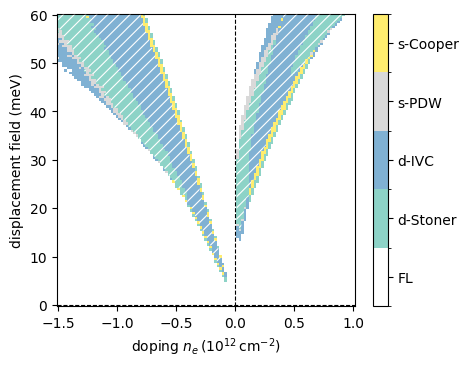

In [14]:
V0 = 16
U4 = tensor(V0,J=-4)
U_bse = split_vertex(U4,chi_ph=chi_ph,chi_pp=chi_pp)
U_rpa = split_vertex(U4)
bse = phase_diagram(chi_ph=chi_ph,chi_pp=chi_pp,vertex=U_bse)
rpa = phase_diagram(chi_ph=chi_ph,chi_pp=chi_pp,vertex=U_rpa)

plot_phase_diagram(
    data["x_grid"],
    data["y_grid"],
    rpa,bse, # set rpa, bse here will have rpa and bse phase
    cmap_name="Set3",
)

(<Figure size 480x380 with 2 Axes>,
 <Axes: xlabel='doping $n_e\\,(10^{12}\\,\\mathrm{cm}^{-2})$', ylabel='displacement field (meV)'>,
 <matplotlib.collections.QuadMesh at 0x40019a4cf170>)

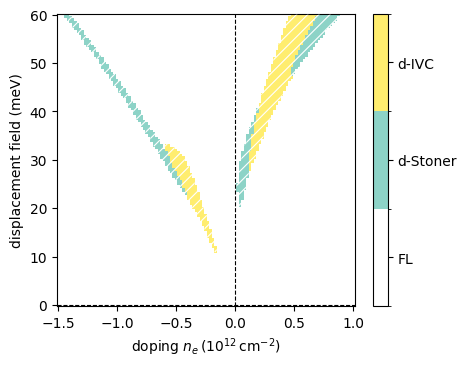

In [15]:
V0 = 19
U4 = tensor(V0,J=0)
U_bse = split_vertex(U4,chi_ph=chi_ph,chi_pp=chi_pp)
U_rpa = split_vertex(U4)
bse = phase_diagram(chi_ph=chi_ph,chi_pp=chi_pp,vertex=U_bse)
rpa = phase_diagram(chi_ph=chi_ph,chi_pp=chi_pp,vertex=U_rpa)

plot_phase_diagram(
    data["x_grid"],
    data["y_grid"],
    rpa,rpa, # set rpa, rpa here will remove the bse phase
    cmap_name="Set3",
)

## different twist angle

I would not trust the $\theta>2^\circ$

In [16]:
brg = RhombohedralMultilayer(theta=0, nlayer=2, twist=0)

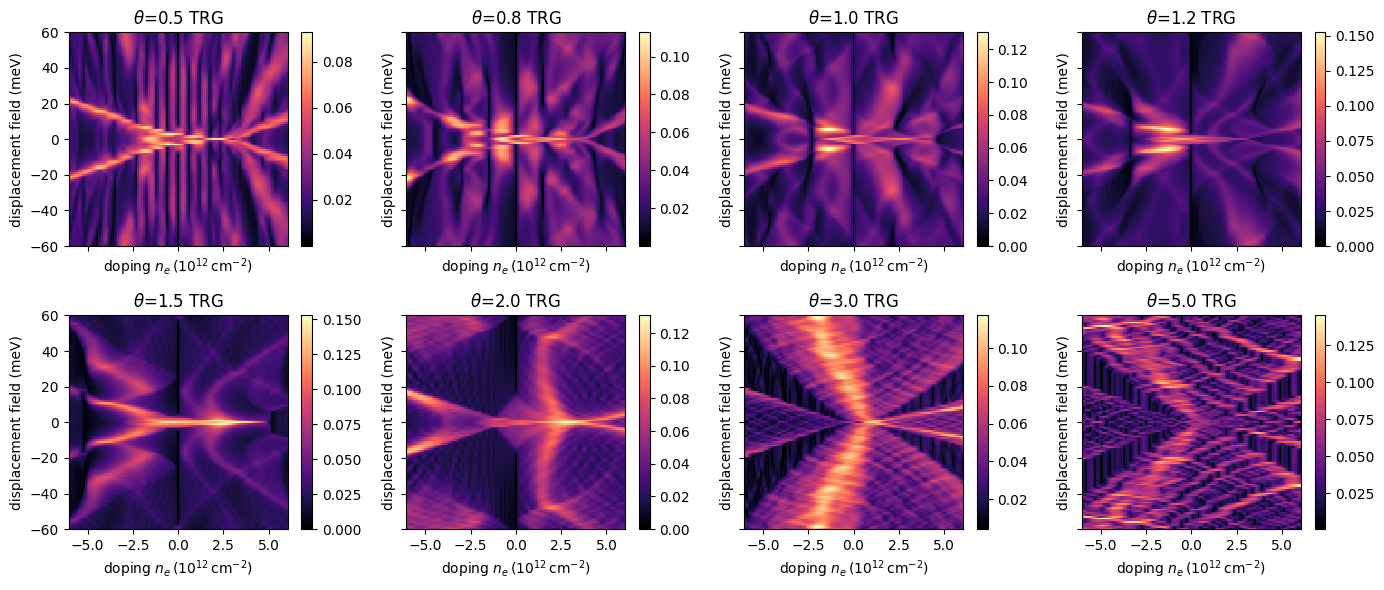

In [18]:
fig, axs = plt.subplots(2,4,figsize=(14,6),sharex=True, sharey=True)
for ax, th in zip(axs.ravel(),[0.5,0.8,1.0,1.2,1.5,2.0,3.0,5.0]):
    data = np.load(f"trg-{th}.npz")
    chi_ph = data["chi_ph_map"]
    chi_pp = data["chi_pp_map"]
    
    trg = RhombohedralMultilayer(theta=th)
    coeff = np.linalg.det(brg.cell)/np.linalg.det(trg.cell)

    im = ax.pcolormesh(data["x_grid"], 
                       data["y_grid"], 
                  chi_ph[:,:,0,0,0,0].T * coeff,
                  cmap="magma", 
                  # norm=norm, 
                  shading="auto", 
                  rasterized=True)

    cbar = fig.colorbar(im, ax=ax)
    ax.set_xlabel(r"doping $n_e\,(10^{12}\,\mathrm{cm}^{-2})$")
    ax.set_ylabel(r"displacement field (meV)")
    
    ax.set_title(fr'$\theta$={th} TRG')
    ax.set_ylim(-60,60)
plt.tight_layout()

theta= 0.5 chi_ph 0.09264697053797508
theta= 0.5 chi_pp -0.08123790464078852
theta= 0.8 chi_ph 0.11277078035092893
theta= 0.8 chi_pp -0.09596939320546104
theta= 1.0 chi_ph 0.13040540590509286
theta= 1.0 chi_pp -0.09770395814655163
theta= 1.2 chi_ph 0.15254485138656304
theta= 1.2 chi_pp -0.11189171444987854
theta= 1.5 chi_ph 0.15285956281495977
theta= 1.5 chi_pp -0.1450989044620857
theta= 2.0 chi_ph 0.148040284432275
theta= 2.0 chi_pp -0.17560960944568801
theta= 3.0 chi_ph 0.22103656934466007
theta= 3.0 chi_pp -0.24189867650313993
theta= 5.0 chi_ph 0.367468499345586
theta= 5.0 chi_pp -0.40020291487402637


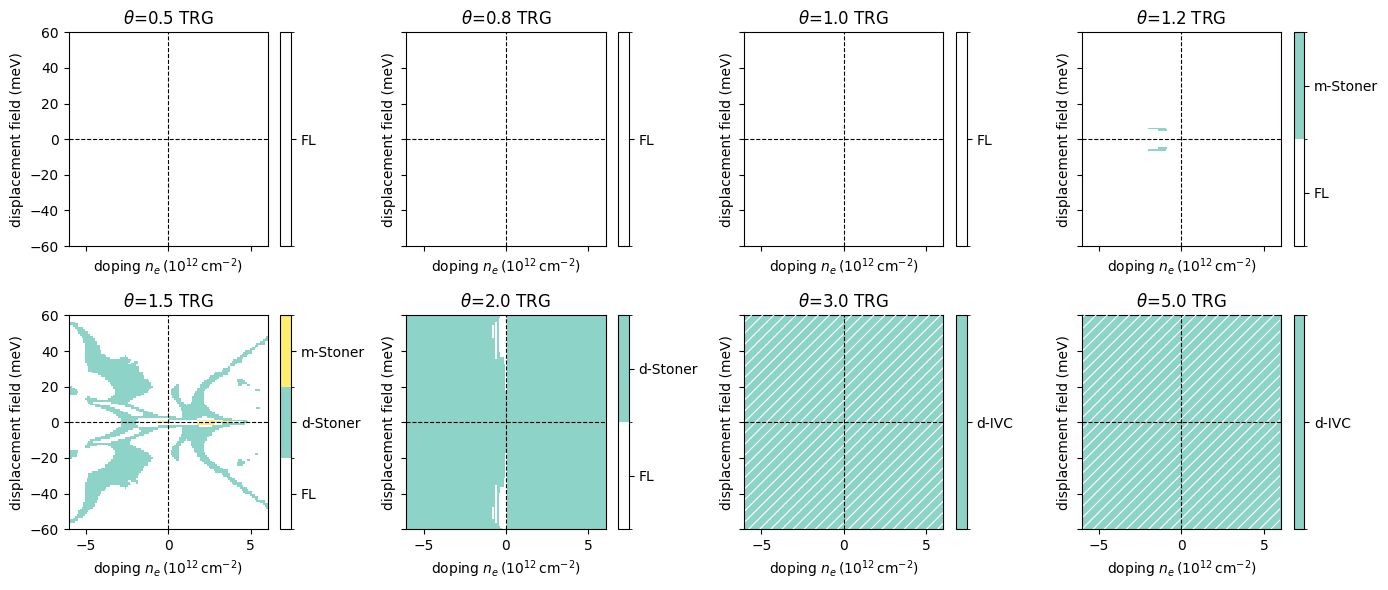

In [20]:
fig, axs = plt.subplots(2,4,figsize=(14,6),sharex=True, sharey=True)
for ax, th in zip(axs.ravel(),[0.5,0.8,1.0,1.2,1.5,2.0,3.0,5.0]):
    trg = RhombohedralMultilayer(theta=th)
    coeff = np.linalg.det(brg.cell)/ np.linalg.det(trg.cell)
    
    data = np.load(f"trg-{th}.npz")
    chi_ph = data["chi_ph_map"]*coeff
    chi_pp = data["chi_pp_map"]*coeff
    
    print('theta=',th,'chi_ph',np.max(chi_ph))
    print('theta=',th,'chi_pp',np.min(chi_pp))

    V0=6
    U4 = tensor(V0,J=0)

    bse = split_vertex(U4,chi_ph=chi_ph,chi_pp=chi_pp)
    rpa = split_vertex(U4)
    bse = phase_diagram(chi_ph=chi_ph,chi_pp=chi_pp,vertex=bse)
    rpa = phase_diagram(chi_ph=chi_ph,chi_pp=chi_pp,vertex=rpa)
    phase = bse.copy(); phase[rpa>0] = rpa[rpa>0]

    plot_phase_diagram(
        data["x_grid"],
        data["y_grid"],
        rpa,bse,ax=ax,
        cmap_name="Set3",
        # phases=[0,1,2,3]
    )

    ax.set_xlabel(r"doping $n_e\,(10^{12}\,\mathrm{cm}^{-2})$")
    ax.set_ylabel(r"displacement field (meV)")
    
    ax.set_title(fr'$\theta$={th} TRG')
    ax.set_ylim(-60,60)
plt.tight_layout()